# In this notebook we report the code used to train the model on the Independent Gaussian Distributions dataset. 

We import the necessary libraries. Note that we use the spectraltools library, from which we import the Spectral layer that can be used as a Keras layer.

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from spectraltools import Spectral
from tensorflow import keras

The Sequential class in tf.keras is used to build the model layer-by-layer. A Spectral layer is used as first layer.

In [4]:
# SPECTRAL NN MODEL

def spectral_model():
    mod = tf.keras.Sequential()
    mod.add(tf.keras.Input(shape=(x_train.shape[1])))
    mod.add(Spectral(units=100,
                     is_base_trainable=True,
                     is_diag_end_trainable=False,
                     is_diag_start_trainable=True,
                     activation='tanh',
                     use_bias=True,
                     diag_end_initializer='Zeros',
                     diag_start_initializer='Ones',
                     diag_regularizer=tf.keras.regularizers.L2(l2=1e-6),
                     base_regularizer=tf.keras.regularizers.L2(l2=1e-2)))
    mod.add(tf.keras.layers.BatchNormalization())
    mod.add(tf.keras.layers.Dropout(0.2))
    mod.add(Spectral(units=100,
                     is_base_trainable=True,
                     is_diag_end_trainable=False,
                     is_diag_start_trainable=True,
                     activation='relu',
                     use_bias=True,
                     diag_end_initializer='Zeros',
                     diag_start_initializer='Ones'))
    mod.add(Spectral(units=50,
                     is_base_trainable=True,
                     is_diag_end_trainable=False,
                     is_diag_start_trainable=True,
                     activation='relu',
                     use_bias=True,
                     diag_end_initializer='Zeros',
                     diag_start_initializer='Ones'))
    mod.add(Spectral(2,
                     is_base_trainable=True,
                     is_diag_end_trainable=False,
                     is_diag_start_trainable=True,
                     activation='softmax',
                     use_bias=True,
                     diag_end_initializer='Zeros',
                     diag_start_initializer='Ones'))
    return mod

We generate the Independent Gaussian Distributions dataset as described in the manuscript. Several parameters can be adjusted to increase or decrease the number of features (n_features), the number of relevant features (n_relevant), the number of examples (n_examples), the number of classes (n_classes), and the standard deviation of the distributions (sigma).

The distributions of the input components are plotted along with their corresponding relevance.

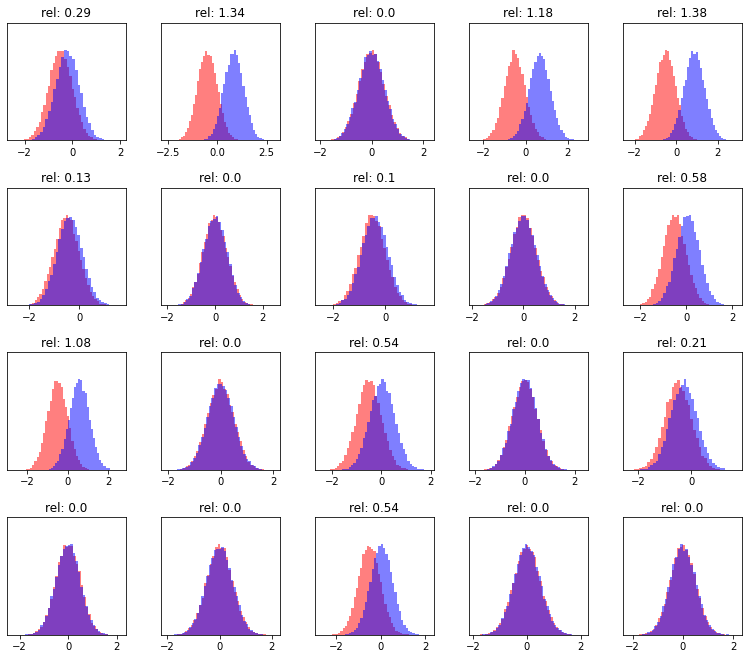

In [5]:
n_features = 20
n_relevant = 11
n_examples = 60000
n_classes = 2
sigma = 0.5

perm = np.random.permutation(np.arange(n_features))
rel_indexes = perm[:n_relevant]
not_rel_indexes = perm[n_relevant:]

relative_relevance = np.random.uniform(0.,1.4, n_features)
relative_relevance[not_rel_indexes] = 0

x = np.zeros((n_examples, n_features))
y = np.random.randint(0,n_classes, n_examples)

mu_array = np.zeros((n_features, n_classes))

i=0
for f in rel_indexes:
    mu_array[f,:] =np.arange(n_classes)*(relative_relevance[f])  - np.mean(np.arange(n_classes))  # np.random.uniform(-2,2, n_classes)*3

for f in range(n_features):
    for c in range(n_classes):
        x[y==c,f]= np.random.normal(mu_array[f,c], sigma, len(y[y==c]))

cl0 = x[y==0]
cl1 = x[y==1]

#define train and test set
x_train, x_test = x[:int(x.shape[0]*0.8)], x[int(x.shape[0]*0.8):]
y_train, y_test = y[:int(y.shape[0]*0.8)], y[int(y.shape[0]*0.8):]


#plot distributions 
cl0 = x[y == 0]
cl1 = x[y == 1]
maxs = []
for i in range(n_features):
    maxs.append(max(list(np.histogram(cl0[:, i], 40,density=True)[0]) + list(np.histogram(cl1[:, i], 40, density=True)[0])))


fig, ax = plt.subplots(4, 5, figsize=(12, 10))
i = 0
for r in range(4):
    for c in range(5):
        if i < x.shape[1]:
            ax[r, c].hist(cl0[:, i], 40, color='r', alpha=0.5, density=True)
            ax[r, c].hist(cl1[:, i], 40, color='b', alpha=0.5, density=True)
            ax[r, c].tick_params(left=False)  # remove the ticks
            ax[r, c].set_yticklabels([])
            ax[r, c].set_ylim([0, 1.3 * maxs[i]])
            ax[r,c].set_title('rel: '+str(np.around(relative_relevance[i],2)))
        i += 1
plt.subplots_adjust(left=0.1, right=0.95, top=0.95, bottom=0.1, wspace=0.3, hspace=0.4)
plt.show()




We train multiple models on the dataset. Here, we set the number of models trained (n_experiments) to 2, while the results reported in the manuscript correspond to n_experiments = 10.

In [6]:
# Spectral NN training

n_experiments=2 # we used 10
list_results=[]
for i in range(n_experiments):
    mod = spectral_model()
    mod.compile(
        optimizer=tf.keras.optimizers.Adam(0.01),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics='accuracy',
    )
    hist = mod.fit(x_train, y_train,
                   batch_size=500,
                   epochs=100, # we used 1000
                   validation_split=0.1,
                   verbose=1)

    eig_start = Spectral.return_diag(mod.layers[0])
    base_start = mod.layers[0].base
    norma = tf.linalg.norm(base_start, ord=2, axis=1)
    eig_norm = (eig_start * norma)
    list_results.append(eig_norm)

Epoch 1/100
87/87 [==============================] - 5s 18ms/step - loss: 0.0874 - accuracy: 0.9905 - val_loss: 0.0559 - val_accuracy: 0.9960
Epoch 2/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0219 - accuracy: 0.9956 - val_loss: 0.0824 - val_accuracy: 0.9890
Epoch 3/100
87/87 [==============================] - 1s 10ms/step - loss: 0.0189 - accuracy: 0.9957 - val_loss: 0.0280 - val_accuracy: 0.9935
Epoch 4/100
87/87 [==============================] - 1s 10ms/step - loss: 0.0196 - accuracy: 0.9955 - val_loss: 0.0183 - val_accuracy: 0.9965
Epoch 5/100
87/87 [==============================] - 1s 10ms/step - loss: 0.0185 - accuracy: 0.9955 - val_loss: 0.0146 - val_accuracy: 0.9969
Epoch 6/100
87/87 [==============================] - 1s 10ms/step - loss: 0.0158 - accuracy: 0.9963 - val_loss: 0.0172 - val_accuracy: 0.9942
Epoch 7/100
87/87 [==============================] - 1s 10ms/step - loss: 0.0177 - accuracy: 0.9958 - val_loss: 0.0167 - val_accuracy: 0.9954
Epoch 

87/87 [==============================] - 1s 11ms/step - loss: 0.0141 - accuracy: 0.9963 - val_loss: 0.0147 - val_accuracy: 0.9940
Epoch 59/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0139 - accuracy: 0.9961 - val_loss: 0.0100 - val_accuracy: 0.9971
Epoch 60/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0131 - accuracy: 0.9966 - val_loss: 0.0117 - val_accuracy: 0.9958
Epoch 61/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0146 - accuracy: 0.9958 - val_loss: 0.0096 - val_accuracy: 0.9975
Epoch 62/100
87/87 [==============================] - 1s 10ms/step - loss: 0.0137 - accuracy: 0.9962 - val_loss: 0.0132 - val_accuracy: 0.9962
Epoch 63/100
87/87 [==============================] - 1s 10ms/step - loss: 0.0143 - accuracy: 0.9962 - val_loss: 0.0129 - val_accuracy: 0.9956
Epoch 64/100
87/87 [==============================] - 1s 10ms/step - loss: 0.0140 - accuracy: 0.9962 - val_loss: 0.0156 - val_accuracy: 0.9950
Epoch 65/100

87/87 [==============================] - 1s 11ms/step - loss: 0.0150 - accuracy: 0.9960 - val_loss: 0.0131 - val_accuracy: 0.9967
Epoch 16/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0164 - accuracy: 0.9959 - val_loss: 0.0116 - val_accuracy: 0.9975
Epoch 17/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0155 - accuracy: 0.9962 - val_loss: 0.0119 - val_accuracy: 0.9971
Epoch 18/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0154 - accuracy: 0.9959 - val_loss: 0.0149 - val_accuracy: 0.9952
Epoch 19/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0148 - accuracy: 0.9962 - val_loss: 0.0155 - val_accuracy: 0.9965
Epoch 20/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0164 - accuracy: 0.9960 - val_loss: 0.0124 - val_accuracy: 0.9965
Epoch 21/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0148 - accuracy: 0.9961 - val_loss: 0.0166 - val_accuracy: 0.9944
Epoch 22/100

87/87 [==============================] - 1s 9ms/step - loss: 0.0137 - accuracy: 0.9963 - val_loss: 0.0123 - val_accuracy: 0.9969
Epoch 73/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0139 - accuracy: 0.9962 - val_loss: 0.0201 - val_accuracy: 0.9937
Epoch 74/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0144 - accuracy: 0.9962 - val_loss: 0.0133 - val_accuracy: 0.9954
Epoch 75/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0150 - accuracy: 0.9957 - val_loss: 0.0125 - val_accuracy: 0.9962
Epoch 76/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0150 - accuracy: 0.9958 - val_loss: 0.0165 - val_accuracy: 0.9958
Epoch 77/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0140 - accuracy: 0.9961 - val_loss: 0.0103 - val_accuracy: 0.9973
Epoch 78/100
87/87 [==============================] - 1s 11ms/step - loss: 0.0140 - accuracy: 0.9964 - val_loss: 0.0098 - val_accuracy: 0.9977
Epoch 79/100


The results are plotted as follows. The first image shows the mean of the eigenvalues of the first layer across the n_experiments models, along with the corresponding standard deviation. The second image shows the same values plotted against node relevance.

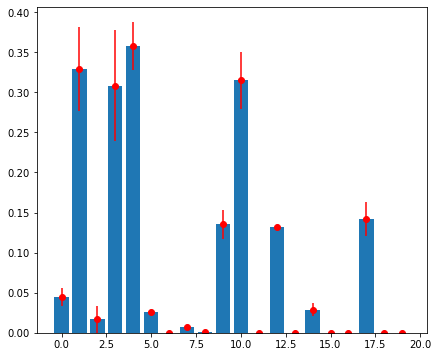

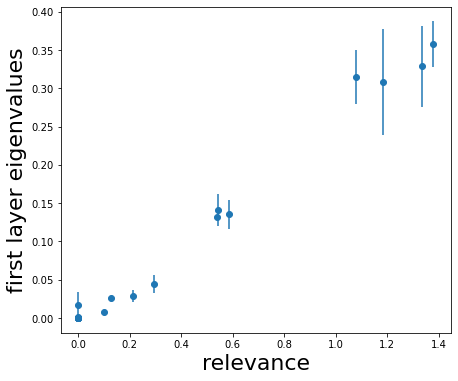

In [8]:
#Plotting the results
arr = np.zeros((len(list_results), list_results[0].shape[0]))
for i in range(len(list_results)):
    arr[i,:] = np.abs(list_results[i].numpy())
mean = arr.mean(axis=0)
std = arr.std(axis=0)

plt.figure(figsize=(7,6))
plt.bar(np.arange(n_features),mean)
plt.errorbar(np.arange(n_features), mean, yerr=std, marker='o', linestyle='none', color='r')
plt.show()

plt.figure(figsize=(7,6))
plt.errorbar(relative_relevance, mean, yerr=std, marker='o', linestyle='none')
plt.xlabel('relevance',fontsize=22)
plt.ylabel('first layer eigenvalues', fontsize=22)
plt.show()